# Maximum likelihood fit of a line using emcee

This notebook follows the same basic idea as the emcee line-fitting tutorial: fit a straight line

$$
y = mx + b + \epsilon
$$

with Gaussian noise by sampling from the posterior distribution using Markov Chain Monte Carlo.


Maximum likelihood estimates:
m = -1.283
b = 5.687
m = -1.2841 +0.0137 / -0.0133
b = 5.6899 +0.0880 / -0.0889


/tmp/ipykernel_363523/1880722613.py:80: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.savefig("Figures/maximum_likelihood_corner.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_363523/1880722613.py:80: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.savefig("Figures/maximum_likelihood_corner.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_363523/1880722613.py:80: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.savefig("Figures/maximum_likelihood_corner.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_363523/1880722613.py:80: MatplotlibDeprecationWarning: savefig() got unexpected keyword a

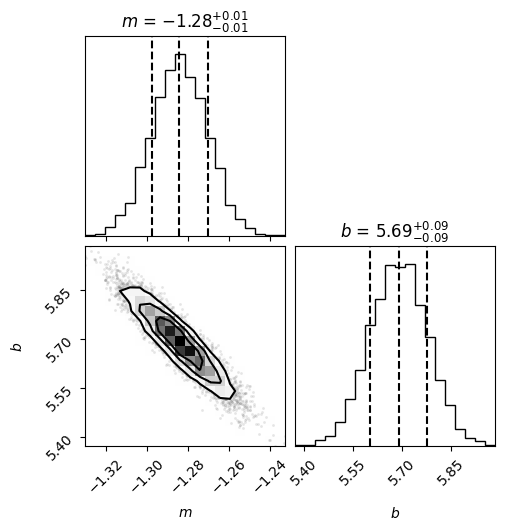

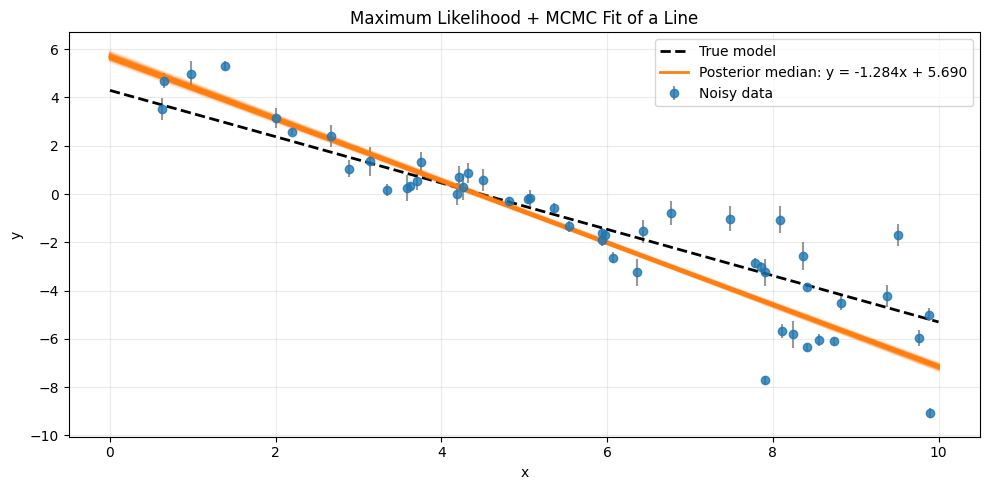

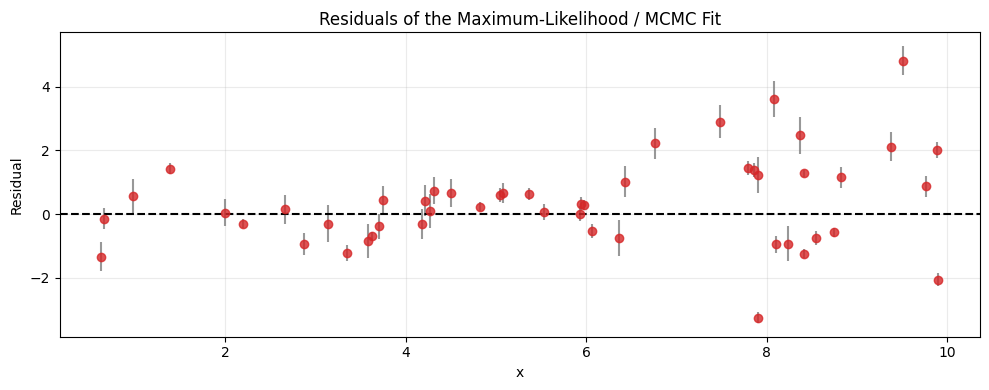

In [3]:
import os

import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize



# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)


def log_likelihood(theta, x, y, yerr):
    m, b = theta
    model = m * x + b
    return -0.5 * np.sum(((y - model) / yerr) ** 2 + np.log(2.0 * np.pi * yerr ** 2))


def log_prior(theta):
    m, b = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0:
        return 0.0
    return -np.inf


def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)


# Maximum-likelihood estimate from a local minimization
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true]) + 0.1 * rng.normal(size=2)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))

ndim = 2
nwalkers = 32
nsteps = 3000
initial = np.array([m_ml, b_ml]) + 1e-4 * rng.normal(size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(initial, nsteps, progress=False)

samples = sampler.get_chain(discard=100, thin=15, flat=True)
m_samples = samples[:, 0]
b_samples = samples[:, 1]

m_16, m_50, m_84 = np.percentile(m_samples, [16, 50, 84])
b_16, b_50, b_84 = np.percentile(b_samples, [16, 50, 84])

print(f"m = {m_50:.4f} +{m_84 - m_50:.4f} / -{m_50 - m_16:.4f}")
print(f"b = {b_50:.4f} +{b_84 - b_50:.4f} / -{b_50 - b_16:.4f}")

fig = corner.corner(
    samples,
    labels=[r"$m$", r"$b$"],
    truths=[m_true, b_true],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
)
fig.savefig("Figures/maximum_likelihood_corner.png", dpi=300, bbox_inches="tight")

plt.figure(figsize=(10, 5))
plt.errorbar(x, y, yerr=yerr, fmt="o", color="tab:blue", ecolor="tab:gray", alpha=0.8, label="Noisy data")
plt.plot(true_x, m_true * true_x + b_true, "--", color="black", linewidth=2, label="True model")

for m, b in samples[np.random.choice(len(samples), 200, replace=False)]:
    plt.plot(true_x, m * true_x + b, color="tab:orange", alpha=0.05)

plt.plot(true_x, np.median(m_samples) * true_x + np.median(b_samples), color="tab:orange", linewidth=2,
         label=f"Posterior median: y = {np.median(m_samples):.3f}x + {np.median(b_samples):.3f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Maximum Likelihood + MCMC Fit of a Line")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/maximum_likelihood_fit.png", dpi=300, bbox_inches="tight")

plt.figure(figsize=(10, 4))
residuals = y - (np.median(m_samples) * x + np.median(b_samples))
plt.errorbar(x, residuals, yerr=yerr, fmt="o", color="tab:red", ecolor="tab:gray", alpha=0.8)
plt.axhline(0.0, color="black", linewidth=1.5, linestyle="--")
plt.xlabel("x")
plt.ylabel("Residual")
plt.title("Residuals of the Maximum-Likelihood / MCMC Fit")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("Figures/maximum_likelihood_residuals.png", dpi=300, bbox_inches="tight")

plt.show()